In [1]:
from pathlib import Path
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEANED_PARQUET_PATH = PROJECT_ROOT / "data/processed/cleaned_yellow_taxi.parquet"

In [3]:
cleaned_lf = pl.scan_parquet(CLEANED_PARQUET_PATH)
cleaned_lf.head(5).collect()

tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,total_amount
datetime[μs],datetime[μs],i32,f32,i32,i32,f32
2025-03-31 08:25:18,2025-03-31 08:31:33,1,0.92,164,233,13.65
2025-03-31 08:35:17,2025-03-31 08:56:30,1,10.55,229,138,59.59
2025-03-31 08:45:27,2025-03-31 08:59:43,1,2.8,79,162,20.65
2025-03-31 08:12:55,2025-03-31 08:21:41,1,1.5,263,163,19.35
2025-03-31 08:21:32,2025-03-31 08:33:03,1,1.57,224,186,18.0


Summary Statisitics

In [6]:
mean_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).mean()).collect(streaming=True)
median_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).median()).collect(streaming=True)
print("Mean columns: \n",mean_lf)
print("Median columns: \n", median_lf)

C:\Users\HP\AppData\Local\Temp\ipykernel_11620\3117956743.py:1: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  mean_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).mean()).collect(streaming=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_11620\3117956743.py:2: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  median_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).median()).collect(streaming=True)


Mean columns: 
 shape: (1, 3)
┌─────────────────┬───────────────┬──────────────┐
│ passenger_count ┆ trip_distance ┆ total_amount │
│ ---             ┆ ---           ┆ ---          │
│ f64             ┆ f32           ┆ f32          │
╞═════════════════╪═══════════════╪══════════════╡
│ 1.302704        ┆ 3.514876      ┆ 29.65308     │
└─────────────────┴───────────────┴──────────────┘
Median columns: 
 shape: (1, 3)
┌─────────────────┬───────────────┬──────────────┐
│ passenger_count ┆ trip_distance ┆ total_amount │
│ ---             ┆ ---           ┆ ---          │
│ f64             ┆ f32           ┆ f32          │
╞═════════════════╪═══════════════╪══════════════╡
│ 1.0             ┆ 1.7           ┆ 21.75        │
└─────────────────┴───────────────┴──────────────┘


Passenger count is fair, while trip distance and total amount are right skewed

Let's now take a look at their distributions...

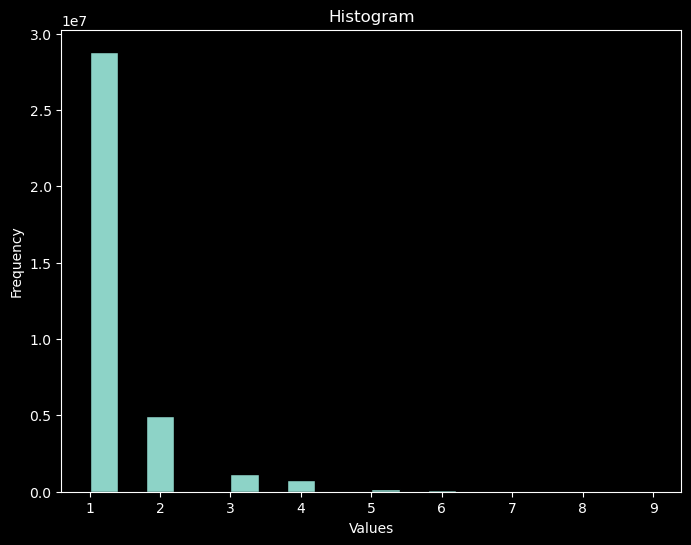

In [9]:
plt.figure(figsize=(8, 6))
plt.hist(cleaned_lf.select(pl.col("passenger_count")).collect(), bins=20, edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

Passenger count is a discrete variable taking small integer values (1, 2, 3, …). Most trips have 1 passenger, so the median and mode are both 1, while a smaller number of trips with 2 or more passengers pull the mean up to about 1.3. This pattern (mean > median with many low values and a few higher ones) indicates that the passenger_count distribution is right‑skewed rather than symmetric. So I made a mistake with what i said earlier.

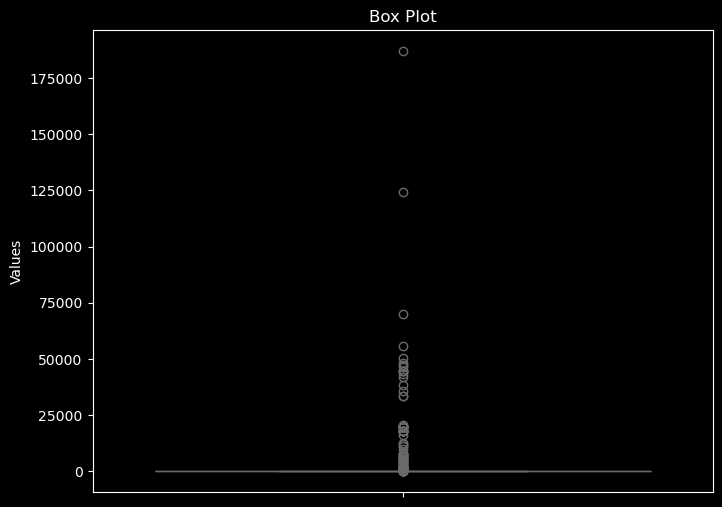

In [12]:
pdf = cleaned_lf.select("trip_distance").collect().to_pandas()
plt.figure(figsize=(8, 6))
sns.boxplot(data=pdf, y='trip_distance')
plt.ylabel('Values')
plt.title('Box Plot')
plt.show()

I don't know how i didn't realize earlier that trip distance must be having an issue! The plot clearly shows i have some massive outliers... so massive that you can barely see the "normal" trips distribution. We literally have values in thousands of miles! According to the TLC data dictionary, trip_distance is the taximeter‑reported trip distance in miles. While very long trips are theoretically possible, most NYC taxi trips are relatively short, and previous studies show a right‑skewed distribution with some outliers. In our data, we observe extremely large values (e.g., tens of thousands of miles) that are implausible given the NYC region and likely represent data errors.

In [ ]:
percentile_list = [0.25, 0.50, 0.75, 0.95, 0.99]
results = pdf['trip_distance'].quantile(percentile_list)
print(results)

0.25     1.00
0.50     1.70
0.75     3.28
0.95    14.90
0.99    20.00
Name: trip_distance, dtype: float64


In our sample, 99% of NYC taxi trips are shorter than about 20 miles; therefore we treat trips with distances much larger than this as outliers or data errors and optionally filter above a data‑driven cutoff (in this case, the 99th percentile).

In [16]:
per_99 = pdf['trip_distance'].quantile(0.99)
cleaned_lf = cleaned_lf.filter((pl.col('trip_distance') <= per_99))

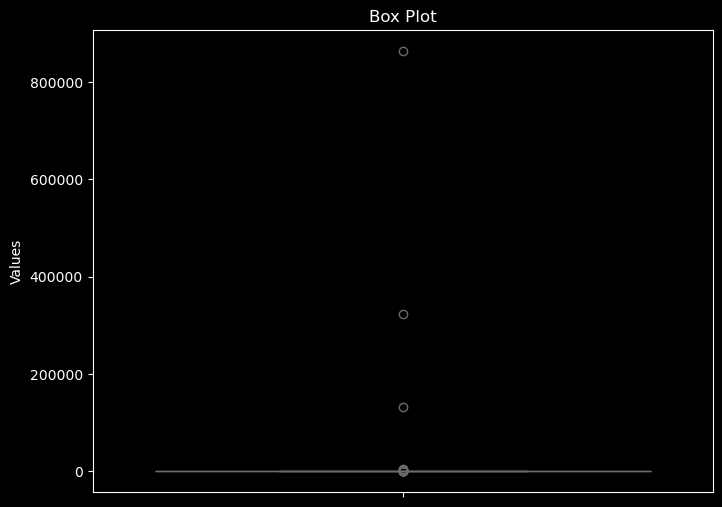

In [17]:
pdf = cleaned_lf.select("total_amount").collect().to_pandas()
plt.figure(figsize=(8, 6))
sns.boxplot(data=pdf, y='total_amount')
plt.ylabel('Values')
plt.title('Box Plot')
plt.show()

It seems to be the same story with total amount... let's check the percentiles...

In [18]:
percentile_list = [0.25, 0.50, 0.75, 0.95, 0.99]
results = pdf['total_amount'].quantile(percentile_list)
print(results)

0.25     16.450001
0.50     21.549999
0.75     31.049999
0.95     80.940002
0.99    103.500000
Name: total_amount, dtype: float64


Indeed it's most likely a case of bad data again... Let's filter this as well...

In [19]:
per_99 = pdf['total_amount'].quantile(0.99)
cleaned_lf = cleaned_lf.filter((pl.col('total_amount') <= per_99))

In [21]:
len(cleaned_lf.collect())

35323229

I guess we will have to check on the distribution of the trips in terms of frequency per day of month or month to see the effects of the rows removed and how to deal with it... we may have to do prediction of highest demand per day for a certain location.